# AI Pulse -- Gold 분석 및 수동 검수

## 1. 범위와 수집 한계

이 노트북은 `collector.py`가 Algolia 검색 API로 수집한 Hacker News story만 분석한다. 수집 대상은 제목/본문에서 `config.BROAD_KEYWORDS`와 `config.TRACKED_KEYWORDS`에 매칭된 story이며, 이 MVP에서는 연속 스케줄러 없이 **수동** `--backfill`/증분 실행으로 수집했다. 따라서 아래 결과는 Hacker News 전체나 더 넓은 AI 뉴스 생태계가 아니라, **현재 수집된 HN story 표본 안의 담론**을 설명한다. 아래의 `points`/`num_comments`는 HN **참여도** 지표일 뿐이며, 이 노트북은 이를 감성이나 조회수 신호로 해석하지 않는다.


In [1]:
import config
import pandas as pd
from db import connect, migrate

conn = connect(config.DB_PATH)
migrate(conn)

print("DB_PATH:", config.DB_PATH)
print("BROAD_KEYWORDS:", config.BROAD_KEYWORDS)
print("TRACKED_KEYWORDS:", config.TRACKED_KEYWORDS)

coverage = pd.read_sql_query(
    "SELECT MIN(created_at) AS earliest, MAX(created_at) AS latest, "
    "COUNT(*) AS story_count FROM stories",
    conn,
)
coverage

DB_PATH: ai_monitor.db
BROAD_KEYWORDS: ['artificial intelligence', 'LLM', 'machine learning', 'AI agent']
TRACKED_KEYWORDS: ['GPT', 'Claude', 'Gemini', 'DeepSeek', 'Qwen', 'Kimi', 'Moonshot AI', 'GLM-4', 'Zhipu AI', 'ERNIE Bot', 'Baidu ERNIE', 'Doubao', 'Hunyuan', 'MiniMax', 'Baichuan', 'Yi-Large', '01.AI', 'Llama', 'Mistral', 'Perplexity', 'Cohere']


,earliest,latest,story_count
0,2026-01-18T11:36:12Z,2026-07-17T11:15:09Z,33505


## 2. 버전 메타데이터

아래 모든 Gold 결과에는 `collection_query_version`, `prompt_version`, `catalog_version`, `as_of`가 포함된다. 그래서 각 그림이 어떤 collector query, extraction prompt, reference-data snapshot에서 나왔는지 추적할 수 있다. `AS_OF`는 벽시계의 `now()`가 아니라 가장 최근에 수집된 story의 timestamp로 고정된다. 같은 데이터베이스로 노트북을 다시 실행하면 같은 시간창과 같은 수치가 재현된다.

이번 최종본에서 시계열, co-occurrence, framing 분석의 공통 조회 기간은 `AS_OF` 기준 최근 180일이다. Family/version 급상승 분석만 최근 24시간과 직전 24시간을 비교한다.


In [2]:
as_of_row = pd.read_sql_query("SELECT MAX(created_at) AS as_of FROM stories", conn).iloc[0]
AS_OF = as_of_row["as_of"] or "2026-07-14T00:00:00Z"  # fallback for an empty database

catalog_versions = pd.read_sql_query(
    "SELECT DISTINCT catalog_version FROM model_catalog", conn
)["catalog_version"].tolist()

print("AS_OF:", AS_OF)
print("config.PROMPT_VERSION:", config.PROMPT_VERSION)
print("config.COLLECTION_QUERY_VERSION:", config.COLLECTION_QUERY_VERSION)
print("model_catalog catalog_version(s) present:", catalog_versions)

AS_OF: 2026-07-17T11:15:09Z
config.PROMPT_VERSION: schema-free-v2
config.COLLECTION_QUERY_VERSION: v2
model_catalog catalog_version(s) present: ['2026-07-17c']


## 3. 데이터셋 규모와 두 가지 Gold 경로

아래 그림에는 서로 독립적인 두 경로가 사용되며, 각 그림이 어느 경로에 의존하는지가 중요하다.

- **Candidate 경로**(4-6장): `candidate_selection.py`가 수집된 모든 story를 버전 관리되는 catalog alias와 오프라인·결정적으로 매칭한다. LLM 출력은 읽지 않으므로 trend와 co-occurrence는 **전체 수집본**을 대상으로 한다.
- **Extraction 경로**(7-9장): 세션이 작성한 Silver extraction이다. `stance`는 이 경로에만 있으므로 framing과 수동 검수는 전체 수집본이 아니라 **추출된 표본**에만 기반한다.

아래 count는 이 두 분모가 얼마나 다른지 보여준다. 모든 framing 수치는 story 전체 수가 아니라 extraction count를 기준으로 읽어야 한다.


In [3]:
from db import catalog_version, latest_successful_extractions

story_count = pd.read_sql_query("SELECT COUNT(*) AS n FROM stories", conn).iloc[0]["n"]
extraction_status_counts = pd.read_sql_query(
    "SELECT status, COUNT(*) AS n FROM story_extractions GROUP BY status", conn
)
latest_success = latest_successful_extractions(conn)

CATALOG_VERSION = catalog_version(conn)
candidate_count = pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM story_candidates WHERE catalog_version = ?",
    conn,
    params=(CATALOG_VERSION,),
).iloc[0]["n"]

print("전체 수집 story 수:", story_count)
print(f"Candidate story 수(catalog {CATALOG_VERSION}):", candidate_count)
print("최신 successful extraction이 있는 story 수:", len(latest_success))
print(f"  -> trend/co-occurrence rest on {candidate_count} stories,"
      f" framing/review on {len(latest_success)}")
extraction_status_counts

전체 수집 story 수: 33505
Candidate story 수(catalog 2026-07-17c): 11204
최신 successful extraction이 있는 story 수: 11037
  -> trend/co-occurrence rest on 11204 stories, framing/review on 11037


,status,n
0,succeeded,11037


## 4. Family trend (`candidate_emerging_models`, `group_level="family"`)

언급 수는 고유 story 기준이다. 한 story에서 같은 family가 두 번 언급되어도 한 번만 센다. `mention_delta`/`mention_growth`는 가장 최근 시간창과 같은 길이의 직전 시간창을 비교한다. `points_sum`/`comments_sum`은 맥락용 참여도 합계이며 ranking에는 사용하지 않는다.

이 분석은 **candidate 경로**에서 실행되므로 추출 표본이 아니라 수집된 모든 story를 포괄한다. 이는 단순히 coverage 때문만은 아니다. extraction 표본은 전체 수집본에서 fixed seed로 뽑히기 때문에 여러 달에 흩어져 있고, 24시간 시간창은 거의 비게 된다. trend에는 최근 시간창의 밀도가 필요하므로 전체 candidate set을 사용한다.


In [4]:
from analysis import candidate_emerging_models

family_trend = candidate_emerging_models(conn, as_of=AS_OF, group_level="family")
family_trend

,vendor,family,version,resolution_status,group_label,recent_story_count,previous_story_count,mention_delta,mention_growth,points_sum,comments_sum,as_of,collection_query_version,catalog_version,candidate_reason
0,Anthropic,Claude,None,resolved,Anthropic/Claude,51,29,22,0.758621,597,472,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
1,Moonshot AI,Kimi,None,resolved,Moonshot AI/Kimi,17,0,17,17.000000,1938,1020,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
2,Anysphere,Cursor,None,resolved,Anysphere/Cursor,7,3,4,1.333333,14,4,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
3,xAI,Grok,None,resolved,xAI/Grok,3,2,1,0.500000,7,0,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
4,Google,Gemini,None,resolved,Google/Gemini,5,5,0,0.000000,357,165,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
5,OpenAI,GPT,None,resolved,OpenAI/GPT,22,23,-1,-0.043478,422,424,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match


/tmp/ipykernel_72545/2847608795.py:10: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/2847608795.py:10: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/2847608795.py:10: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/2847608795.py:10: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/2847608795.py:10: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/2847608795.py:10: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/2847608795.py:10: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  pl

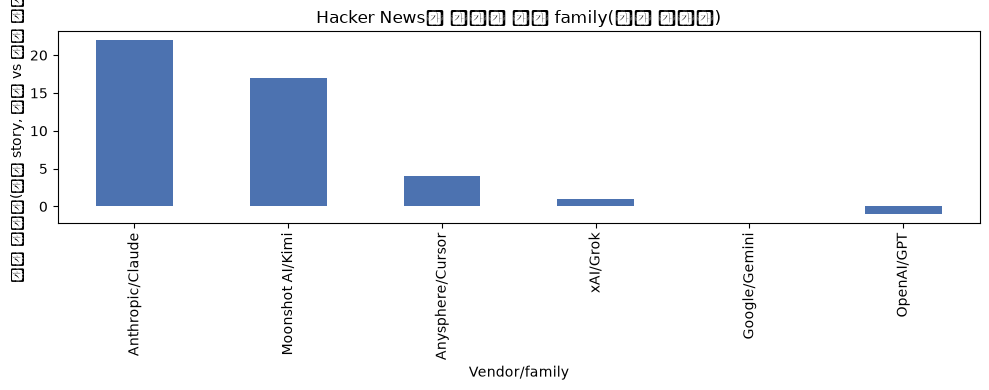

In [5]:
import matplotlib.pyplot as plt

if not family_trend.empty:
    ax = family_trend.set_index("group_label")["mention_delta"].plot(
        kind="bar", figsize=(10, 4), color="#4C72B0"
    )
    ax.set_ylabel("언급 증가량(고유 story, 최근 vs 직전 시간창)")
    ax.set_xlabel("Vendor/family")
    ax.set_title("Hacker News의 급상승 모델 family(언급 증가량)")
    plt.tight_layout()
    plt.show()
else:
    print("현재 시간창/threshold에서 family-level 언급이 없습니다.")

## 5. Version trend (`candidate_emerging_models`, `group_level="version"`)

4장과 같은 계산을 한 단계 더 구체적인 version 수준에서 수행한다. version이 해결되지 않은 언급은 버리지 않고 `"unresolved version"`으로 표시한다.

여기서는 대부분의 행이 unresolved일 가능성이 높다. version alias(`Claude Opus 4.6`, `Gemini 2.0 Flash`, ...)는 catalog에서 **family** record에 붙어 있다. version record를 만들려면 출처가 있는 release가 필요하지만, 많은 surface가 루머이거나 미출시 version을 부르기 때문이다. 따라서 해당 record가 생기기 전까지 version-level trend는 희박하게 남는다.


In [6]:
version_trend = candidate_emerging_models(conn, as_of=AS_OF, group_level="version")
version_trend

,vendor,family,version,resolution_status,group_label,recent_story_count,previous_story_count,mention_delta,mention_growth,points_sum,comments_sum,as_of,collection_query_version,catalog_version,candidate_reason
0,Anthropic,Claude,unresolved version,resolved,Anthropic/Claude/unresolved version,51,29,22,0.758621,597,472,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
1,Moonshot AI,Kimi,unresolved version,resolved,Moonshot AI/Kimi/unresolved version,17,0,17,17.000000,1938,1020,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
2,OpenAI,GPT,5.6 Sol,resolved,OpenAI/GPT/5.6 Sol,6,1,5,5.000000,329,394,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
3,Anysphere,Cursor,unresolved version,resolved,Anysphere/Cursor/unresolved version,7,3,4,1.333333,14,4,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
4,Anthropic,Claude,Opus 4.8,resolved,Anthropic/Claude/Opus 4.8,2,0,2,2.000000,13,5,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
5,xAI,Grok,unresolved version,resolved,xAI/Grok/unresolved version,3,2,1,0.500000,7,0,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
6,Google,Gemini,unresolved version,resolved,Google/Gemini/unresolved version,5,5,0,0.000000,357,165,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
7,OpenAI,GPT,unresolved version,resolved,OpenAI/GPT/unresolved version,22,23,-1,-0.043478,422,424,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match


/tmp/ipykernel_72545/3637159764.py:8: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/3637159764.py:8: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/3637159764.py:8: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/3637159764.py:8: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/3637159764.py:8: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/3637159764.py:8: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/3637159764.py:8: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight

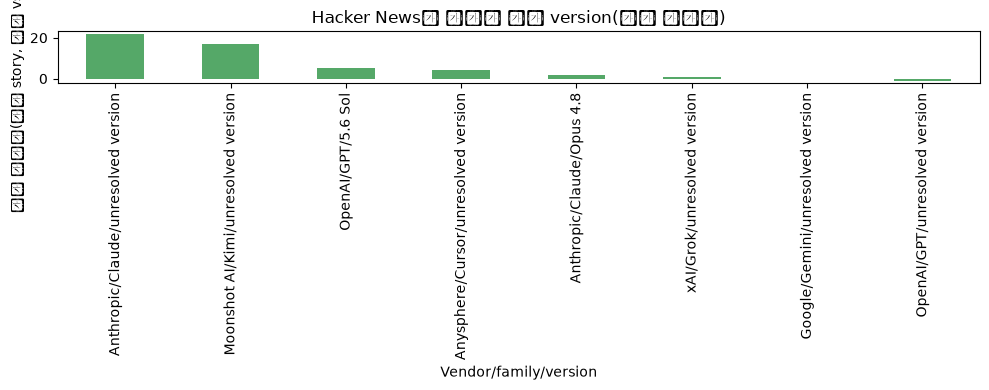

In [7]:
if not version_trend.empty:
    ax = version_trend.set_index("group_label")["mention_delta"].plot(
        kind="bar", figsize=(10, 4), color="#55A868"
    )
    ax.set_ylabel("언급 증가량(고유 story, 최근 vs 직전 시간창)")
    ax.set_xlabel("Vendor/family/version")
    ax.set_title("Hacker News의 급상승 모델 version(언급 증가량)")
    plt.tight_layout()
    plt.show()
else:
    print("현재 시간창/threshold에서 version-level 언급이 없습니다.")

## 5b. Vendor별 모델 라인업(최신성 가중)

위의 family/version trend는 가장 최근 24시간 시간창만 본다. 이 섹션은 해결된 `model_id`별로 **전체 수집 이력**을 보므로, vendor의 실제 라인업이 드러난다. 예를 들어 Anthropic은 Opus 4.7, Opus 4.8, Sonnet 4.6, Mythos를 각각 별도 catalog entry로 보유하며, 하나의 "Claude" 덩어리로 합치지 않는다.

`story_count`는 누적 lifetime count이므로 몇 달 전 launch spike도 오늘 trending인 항목과 동일한 무게로 계산된다. `weighted_count`는 `AS_OF`를 기준으로 각 story의 기여도를 `0.5 ** (age_days / half_life_days)`로 감쇠시킨다(기본 half-life: 30일). 그래서 과거 raw volume보다 최근 언급이 ranking을 지배한다.


In [8]:
from analysis import candidate_model_lineup

lineup = candidate_model_lineup(conn, as_of=AS_OF, half_life_days=30.0)
lineup

,vendor,family,version,model_id,story_count,weighted_count,points_sum,comments_sum,as_of,half_life_days,collection_query_version,catalog_version,candidate_reason
0,Anthropic,Claude,None,anthropic-claude,8183,1562.359340,158525,90608,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
1,Anthropic,Claude,Mythos,anthropic-claude-mythos,143,38.188587,10213,6114,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
2,Anthropic,Claude,Opus 4.8,anthropic-claude-opus-4-8,62,30.859986,2497,1681,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
3,Anthropic,Claude,Opus 4.7,anthropic-claude-opus-4-7,104,18.835989,3741,2214,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
4,Anthropic,Claude,Sonnet 4.6,anthropic-claude-sonnet-4-6,63,7.681421,3438,2128,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,Alibaba,Qwen,3.6,alibaba-qwen-3-6,58,18.842195,5830,2650,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
57,Alibaba,Qwen,3.5,alibaba-qwen-3-5,96,11.728813,3346,1327,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
58,Alibaba,Qwen,3.7,alibaba-qwen-3-7,4,1.134514,263,98,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
59,Alibaba,Qwen,3.5 Flash,alibaba-qwen-3-5-flash,1,0.062489,5,2,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match


## 5c. 언급 시계열(calendar bucket)

Family/version trend(4-5장)는 두 개의 단일 지점, 즉 최근 24시간과 직전 24시간만 비교한다. 위의 lineup(5b)은 전체 이력을 모델별 감쇠 count 하나로 압축한다. 둘 다 시간에 따른 실제 모양을 보여주지는 못한다. 이 섹션은 실제 시계열을 유지한다. 기본값은 최근 180일, 7일 calendar bucket별 고유 story 언급 수이며, spike, plateau, decline이 같은 `delta`나 `weighted count`로 뭉개지지 않고 서로 다르게 보인다.


In [9]:
from analysis import candidate_mention_timeseries

timeseries = candidate_mention_timeseries(conn, as_of=AS_OF, group_level="family", bucket_days=7)
timeseries

,vendor,family,version,resolution_status,group_label,bucket_start,story_count,as_of,bucket_days,collection_query_version,catalog_version,candidate_reason
0,01.AI,Yi,None,resolved,01.AI/Yi,1770981309,1,2026-07-17T11:15:09Z,7,v2,2026-07-17c,catalog_alias_match
1,Alibaba,Qwen,None,resolved,Alibaba/Qwen,1768562109,7,2026-07-17T11:15:09Z,7,v2,2026-07-17c,catalog_alias_match
2,Alibaba,Qwen,None,resolved,Alibaba/Qwen,1769166909,9,2026-07-17T11:15:09Z,7,v2,2026-07-17c,catalog_alias_match
3,Alibaba,Qwen,None,resolved,Alibaba/Qwen,1769771709,1,2026-07-17T11:15:09Z,7,v2,2026-07-17c,catalog_alias_match
4,Alibaba,Qwen,None,resolved,Alibaba/Qwen,1770376509,7,2026-07-17T11:15:09Z,7,v2,2026-07-17c,catalog_alias_match
...,...,...,...,...,...,...,...,...,...,...,...,...
437,xAI,Grok,None,resolved,xAI/Grok,1780658109,2,2026-07-17T11:15:09Z,7,v2,2026-07-17c,catalog_alias_match
438,xAI,Grok,None,resolved,xAI/Grok,1781262909,5,2026-07-17T11:15:09Z,7,v2,2026-07-17c,catalog_alias_match
439,xAI,Grok,None,resolved,xAI/Grok,1782472509,1,2026-07-17T11:15:09Z,7,v2,2026-07-17c,catalog_alias_match
440,xAI,Grok,None,resolved,xAI/Grok,1783077309,5,2026-07-17T11:15:09Z,7,v2,2026-07-17c,catalog_alias_match


/tmp/ipykernel_72545/2104889047.py:15: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/2104889047.py:15: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/2104889047.py:15: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/2104889047.py:15: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/2104889047.py:15: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/2104889047.py:15: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/2104889047.py:15: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tig

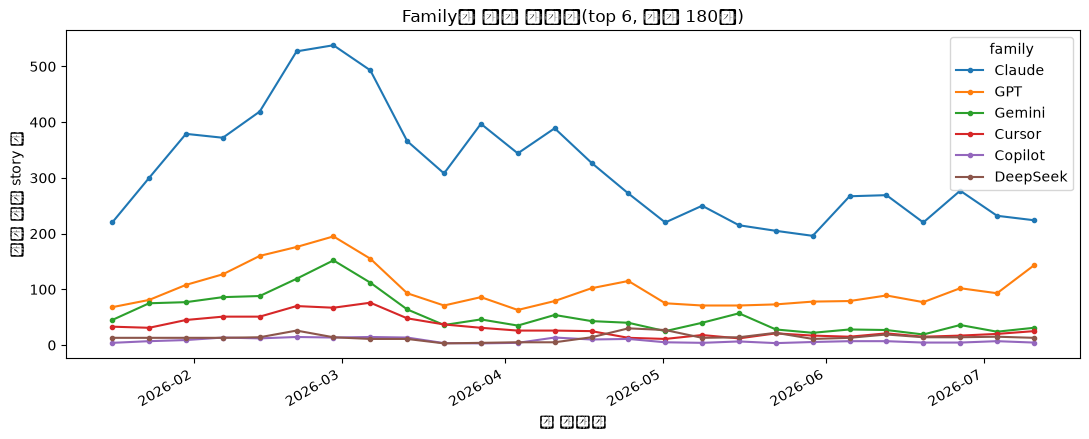

In [10]:
import pandas as pd

if not timeseries.empty:
    top_families = (
        timeseries.groupby("family")["story_count"].sum().sort_values(ascending=False).head(6).index
    )
    pivot = timeseries[timeseries["family"].isin(top_families)].pivot_table(
        index="bucket_start", columns="family", values="story_count", fill_value=0
    )
    pivot.index = pd.to_datetime(pivot.index, unit="s", utc=True)
    ax = pivot[top_families].plot(figsize=(11, 4.5), marker="o", markersize=3)
    ax.set_ylabel("주별 고유 story 수")
    ax.set_xlabel("주 시작일")
    ax.set_title("Family별 주간 언급량(top 6, 최근 180일)")
    plt.tight_layout()
    plt.show()
else:
    print("lookback window에 candidate mention이 없습니다.")

## 6. 모델 co-occurrence

같은 story 안에서 함께 언급된, 서로 다른 resolved model family 쌍을 센다(story당 pair는 한 번만 계산). 무방향 그래프로 시각화하며, edge width는 함께 언급된 story 수에 비례한다.

이 역시 **candidate 경로**에 기반하므로 수집된 모든 story가 기여한다. candidate mention은 구조상 모두 catalog-resolved 상태이므로 여기에는 `unresolved` pair가 나타나지 않는다.


In [11]:
from analysis import candidate_model_cooccurrence

cooccurrence = candidate_model_cooccurrence(
    conn, as_of=AS_OF, group_level="family", lookback_days=180
)
cooccurrence

,vendor_a,family_a,version_a,vendor_b,family_b,version_b,story_count,as_of,collection_query_version,catalog_version,candidate_reason
0,Anthropic,Claude,None,Anysphere,Cursor,None,669,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
1,Anthropic,Claude,None,DeepSeek,DeepSeek,None,83,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
2,Anthropic,Claude,None,Google,Gemini,None,606,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
3,Anthropic,Claude,None,OpenAI,GPT,None,1642,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
4,Anysphere,Cursor,None,DeepSeek,DeepSeek,None,8,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
...,...,...,...,...,...,...,...,...,...,...,...
114,Alibaba,Qwen,None,Xiaomi,Mimo,None,2,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
115,Microsoft,Copilot,None,Mistral AI,Mistral,None,2,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
116,GitHub,Copilot,None,Moonshot AI,Kimi,None,3,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
117,Microsoft,Copilot,None,Moonshot AI,Kimi,None,3,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match


/tmp/ipykernel_72545/3715187291.py:21: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/3715187291.py:21: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/3715187291.py:21: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/3715187291.py:21: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/3715187291.py:21: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/.local/lib/python3.12/site-packages/IPython/core/pylabtools.

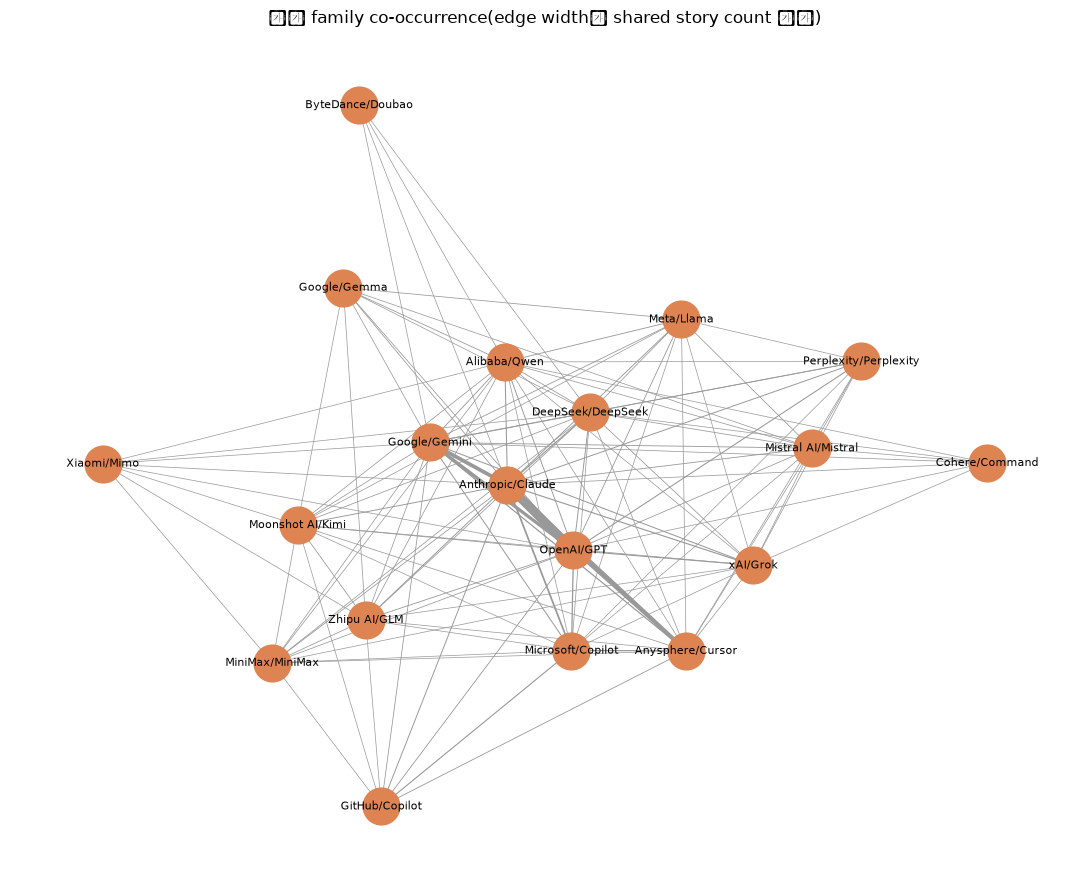

In [12]:
import networkx as nx

if not cooccurrence.empty:
    edges = cooccurrence.assign(
        label_a=cooccurrence["vendor_a"] + "/" + cooccurrence["family_a"],
        label_b=cooccurrence["vendor_b"] + "/" + cooccurrence["family_b"],
    )
    graph = nx.from_pandas_edgelist(edges, "label_a", "label_b", edge_attr="story_count")

    pos = nx.spring_layout(graph, seed=20260714, k=0.6)
    weights = [graph[u][v]["story_count"] for u, v in graph.edges()]
    max_weight = max(weights)
    scaled_widths = [0.5 + 6 * (w / max_weight) for w in weights]
    plt.figure(figsize=(11, 9))
    nx.draw_networkx(
        graph, pos, with_labels=True, node_color="#DD8452", node_size=700,
        font_size=8, width=scaled_widths, edge_color="#999999",
    )
    plt.title("모델 family co-occurrence(edge width는 shared story count 기준)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("현재 min_count threshold에서 함께 언급된 model family pair가 없습니다.")

## 7. 모델 framing

`stance`는 *story*가 모델을 어떻게 평가하는지를 설명한다. 방향은 항상 story → entity이며, entity 자체의 입장이 아니다. 이는 community sentiment나 vote count의 측정값이 **아니다**.

`schema-free-v2`부터 extraction contract는 vocabulary를 완전히 열어두는 대신 각 attribute slot의 의미를 정의한다. `kind`는 surface가 무엇을 가리키는지, `role`은 story의 claim 안에서 어떤 위치인지, `stance`는 story의 평가를, `extensions.framing`은 story 자체의 genre를 나타낸다. `stance`는 `kind`가 `model` 또는 `product`일 때만 설정한다. slot vocabulary는 여전히 open-world다. anchor label(`positive`/`negative`/`neutral`/`mixed`)을 선호하되 맞지 않으면 더 구체적인 label을 허용하고, story만으로 답할 수 없으면 `unresolved`를 사용한다. label은 원문 그대로 저장된다. contract가 제한하는 것은 각 slot이 답해야 할 질문이지, 들어갈 수 있는 단어 목록이 아니다.

`schema-free-v1`에서는 slot이 정의되지 않아 story genre가 `stance`로 섞여 들어갔다(예: `"product launch"`). 그래서 세션 간 stance count를 해석하기 어려웠다. v1 row는 자체 `prompt_version` 아래 history로 보존되며, 이 그림에는 섞지 않는다.


In [13]:
from analysis import model_framing_sentiment

framing = model_framing_sentiment(
    conn, as_of=AS_OF, group_level="family", lookback_days=180
)
framing

,vendor,family,version,resolution_status,group_label,stance,story_count,as_of,collection_query_version,prompt_version,catalog_version
0,Alibaba,Qwen,None,resolved,Alibaba/Qwen,negative,5,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
1,Alibaba,Qwen,None,resolved,Alibaba/Qwen,neutral,60,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
2,Alibaba,Qwen,None,resolved,Alibaba/Qwen,positive,16,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
3,Anthropic,Claude,None,resolved,Anthropic/Claude,mixed,2,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
4,Anthropic,Claude,None,resolved,Anthropic/Claude,negative,843,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
...,...,...,...,...,...,...,...,...,...,...,...
514,None,None,None,unresolved,mistral.rs,positive,1,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
515,None,None,None,unresolved,o3,negative,2,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
516,None,None,None,unresolved,qwen3-8b,neutral,1,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
517,None,None,None,unresolved,superglue,positive,1,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c


/tmp/ipykernel_72545/4153581019.py:12: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/4153581019.py:12: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/4153581019.py:12: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/4153581019.py:12: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/4153581019.py:12: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/4153581019.py:12: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72545/4153581019.py:12: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tigh

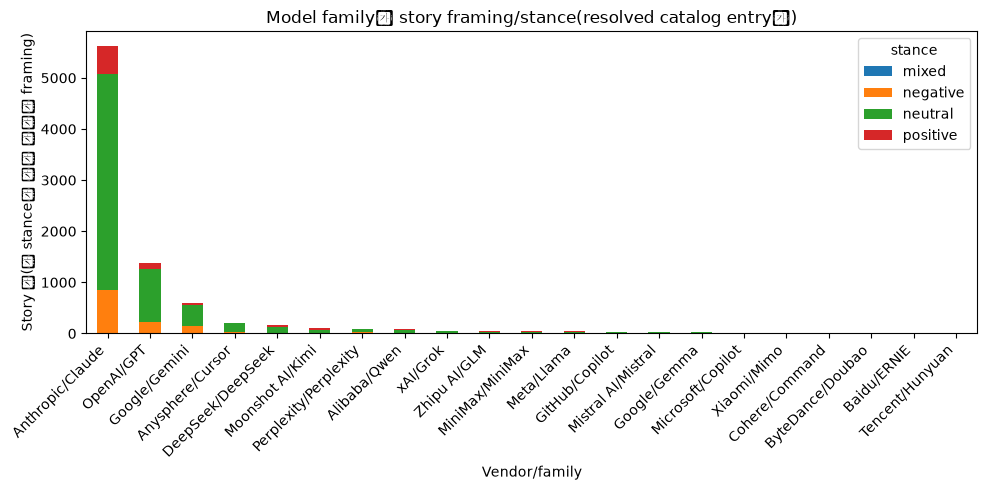

In [14]:
if not framing.empty:
    resolved_framing = framing[framing["resolution_status"] == "resolved"]
    pivot = resolved_framing.pivot_table(
        index="group_label", columns="stance", values="story_count", fill_value=0
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
    ax = pivot.plot(kind="bar", stacked=True, figsize=(10, 5))
    ax.set_ylabel("Story 수(이 stance로 해당 모델을 framing)")
    ax.set_xlabel("Vendor/family")
    ax.set_title("Model family별 story framing/stance(resolved catalog entry만)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("framing/stance label이 있는 observation이 없습니다.")

## 8. Fixed-seed 30-story 검수

최신 successful extraction에서 고정 seed(`seed=20260714`)로 뽑은 30개 story 표본이다. title-only story와 self-post story가 둘 다 존재하면 둘을 모두 포함한다. 같은 seed는 항상 같은 `story_id`를 같은 순서로 반환한다(`tests/test_analysis.py::test_review_sample_is_reproducible` 참고). reviewer column(`is_relevant`, `expected_mentions`, ...)은 비어 있는 상태로 시작하며 `data/manual_review_template.csv`의 header와 일치한다. 사람 reviewer가 이 값을 직접 채운다.


In [15]:
from analysis import review_sample

REVIEW_SEED = 20260714
REVIEW_SAMPLE_SIZE = 30

review = review_sample(conn, sample_size=REVIEW_SAMPLE_SIZE, seed=REVIEW_SEED)
review

,story_id,title,normalized_text,parsed_json,is_relevant,expected_mentions,extracted_mentions,evidence_valid,family_version_mapping_valid,stance_valid,error_type,reviewer_notes
0,46823036,"Chat Memo – Auto-Save AI Chats from ChatGPT, G...",,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
1,47085076,Ask HN: What Is the Point of WebMCP?,"So I have a question that should be simple, bu...","{""relevant"": false, ""observations"": [], ""exten...",None,None,None,None,None,None,None,None
2,47543189,Claude loses its >99% uptime in Q1 2026,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
3,47297392,Cursor went from $0 to $29B to existential thr...,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
4,47545960,Show HN: Control Codex via WhatsApp using a Co...,"Codex plugins were released just yesterday, an...","{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
5,48867766,"Show HN: I made Claude explain like I'm 5, and...",I was burning out reading AI output. So I crea...,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
6,48111970,Can Claude Skills Replace Open Source Software?,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
7,48479452,Claude Desktop spawns 1.8 GB Hyper-V VM on eve...,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
8,47557794,Who Wins If AI Models Commoditize? – With Mist...,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
9,48613373,"Never coded before, now shipping websites to c...","Claude Plans, then executes, then uses Cloudfl...","{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None


In [16]:
# Export for hand annotation. This is local reviewer working data (like
# ai_monitor.db) rather than the versioned template -- decide at review time
# whether the completed copy is worth committing.
review_export_path = "data/manual_review_sample.csv"
review.to_csv(review_export_path, index=False)
print(f"수동 주석용으로 {len(review)}개 row를 {review_export_path}에 기록했습니다.")

수동 주석용으로 30개 row를 data/manual_review_sample.csv에 기록했습니다.


## 9. Precision / recall / evidence-validity 계산

reviewer가 완료된 review CSV에 `expected_mentions`(story별 ground-truth mention count)와 `extracted_mentions`(그중 LLM이 올바르게 추출한 수, 즉 true positive)를 직접 채우면 이 섹션은 다음을 계산한다.

- **recall** = sum(extracted_mentions) / sum(expected_mentions) -- extraction step이 실제 mention 중 찾아낸 비율.
- **precision** = sum(extracted_mentions) / sum(같은 story에서 LLM이 생성했고 evidence가 검증된 observation) -- LLM 출력 중 올바른 비율. 분모는 reviewed story에 대해 `story_extractions.parsed_json`에서 독립적으로 다시 계산한다(Gold와 같은 `evidence_verified` filter 사용). CSV에서 가져오지 않으므로 precision은 reviewer가 false positive를 직접 세는지에 의존하지 않는다.
- **evidence / mapping / stance validity rates** = 해당 yes/no reviewer column의 평균.

이 셀은 reviewer column이 채워진 `data/manual_review_template.csv`의 완료본 또는 8장에서 생성한 `data/manual_review_sample.csv`를 기대한다. 채워진 값이 있는 항목만 보고하며, 없는 label을 만들어내지 않는다.


In [17]:
import json
from pathlib import Path

# Prefer the Section-8 export when present, else fall back to the versioned template.
_sample_path = Path("data/manual_review_sample.csv")
_template_path = Path("data/manual_review_template.csv")
completed_review_path = _sample_path if _sample_path.exists() else _template_path
if not completed_review_path.exists():
    print(f"{completed_review_path}가 없어 아직 계산할 항목이 없습니다.")
else:
    completed = pd.read_csv(completed_review_path)
    completed = completed.dropna(subset=["expected_mentions", "extracted_mentions"])
    if completed.empty:
        print("수동 검수 column이 아직 채워지지 않아 계산할 항목이 없습니다.")
    else:
        reviewed_ids = tuple(completed["story_id"])
        placeholders = ",".join("?" for _ in reviewed_ids)
        parsed = pd.read_sql_query(
            f"SELECT story_id, parsed_json FROM story_extractions "
            f"WHERE status = 'succeeded' AND story_id IN ({placeholders})",
            conn,
            params=reviewed_ids,
        )

        def _observation_count(raw_json: str) -> int:
            envelope = json.loads(raw_json)
            return sum(
                1 for obs in envelope.get("observations", [])
                if obs.get("evidence_verified") is True
            )

        parsed["llm_observation_count"] = parsed["parsed_json"].apply(_observation_count)
        llm_counts = parsed.groupby("story_id")["llm_observation_count"].sum()

        expected_total = completed["expected_mentions"].astype(float).sum()
        extracted_total = completed["extracted_mentions"].astype(float).sum()
        llm_total = completed["story_id"].map(llm_counts).fillna(0).sum()

        recall = extracted_total / expected_total if expected_total else float("nan")
        precision = extracted_total / llm_total if llm_total else float("nan")

        def _validity_rate(column: str) -> float:
            if column not in completed.columns:
                return float("nan")
            values = completed[column].astype(str).str.strip().str.lower()
            return values.isin(["y", "yes", "true", "1"]).mean()

        print(f"count가 채워진 reviewed story 수: {len(completed)}")
        print(f"Recall(추출 mention / 기대 mention): {recall:.2f}")
        print(f"Precision(추출 mention / LLM 생성 observation): {precision:.2f}")
        print(f"Evidence validity rate: {_validity_rate('evidence_valid'):.2f}")
        print(f"Family/version mapping validity rate: {_validity_rate('family_version_mapping_valid'):.2f}")
        print(f"Stance validity rate: {_validity_rate('stance_valid'):.2f}")

수동 검수 column이 아직 채워지지 않아 계산할 항목이 없습니다.


## 10. 한계와 Phase 2

- **수집 coverage**: 설정된 Algolia `BROAD_KEYWORDS`/`TRACKED_KEYWORDS`에 매칭된 story만 수집된다. 또한 수집은 연속 스케줄이 아니라 수동 실행(`collector.py --backfill N` / incremental runs)으로 트리거되므로 실행 사이의 gap이 생길 수 있다.
- **서로 다른 두 분모**: trend와 co-occurrence(4-6장)는 catalog alias matching을 통해 수집된 모든 story에 기반한다. framing과 수동 검수(7-9장)는 훨씬 작은 extraction 표본에만 기반한다. framing count를 전체 수집본의 비율로 읽으면 안 된다.
- **Catalog-bound recall**: candidate 경로는 versioned catalog에 존재하는 model family만 볼 수 있다. catalog 밖의 surface(Grok, Mistral, Llama, Gemma, ...)는 `unresolved`로 남고 family figure에 도달하지 않는다. 따라서 여기서 어떤 family가 없다는 것은 "catalog에 없다"는 뜻이지 "논의되지 않았다"는 뜻이 아니다.
- **Alias precision**: matching은 lexical 방식이므로 모델이 아닌 이름도 매칭될 수 있다. 이 데이터에서는 Gemini crypto exchange가 실제 예시다. extraction step은 이런 경우를 잡아낸다(`relevant: false`). 하지만 candidate 경로만으로는 잡지 못하므로 extraction-verified count보다 candidate count가 부풀 수 있다.
- **Engagement vs. sentiment**: trend figure 옆의 `points`/`num_comments`는 Hacker News 참여도 count일 뿐이다. 이를 sentiment/opinion signal로 사용하거나 이름 바꾸지 않는다. 이 노트북의 유일한 tone signal은 `model_framing_sentiment`의 open-world `stance` field이며, 이는 HN 댓글러의 감정이나 조회수가 아니라 *story*가 모델을 어떻게 framing하는지를 설명한다.
- **Extraction noise**: story당 하나의 session-authored extraction(`config.SESSION_EXTRACTION_MODEL`)과 prompt version만 사용한다. Gold에는 evidence-verified observation만 들어가며, precision/recall/evidence validity는 전체 dataset이 아니라 고정된 30-story 표본만 수동 검수한다.
- **Reference data**: 모델 release date와 benchmark score는 현재 `reference_data.py`/`data/model_catalog.json`에 출처가 있는 항목으로 제한된다. 등록되지 않았거나 unresolved인 surface는 억지로 매칭하지 않고 `unresolved`로 남긴다.
- **이 MVP의 범위 밖**(`docs/superpowers/specs/2026-07-14-ai-pulse-design.md`의 명시적 Phase 2): Reddit 또는 다른 platform, HN comment text, Supabase, formal ontology, hosted MCP server, 자동/스케줄 수집.
